# Surface Embedding & Prediction Explorer

This notebook walks through the two-stage pipeline for predicting cancer drug combination viability surfaces.

**Pipeline:**
1. **GP Surfaces** — pre-fitted Gaussian Process posteriors for ~290 drug pairs on the KPL1 breast cancer cell line. Each surface is a 30×30 grid over dose space (cell viability as a function of concentration of drug A and drug B).
2. **Functional PCA (SVD)** — stack all surfaces into a matrix and decompose into a shared low-rank basis. Each surface is then described by just K=5 coefficients.
3. **MLP Predictor** — a small neural network trained here to predict those 5 coefficients from drug molecular structure, encoded via a pre-trained Transformer VAE.

**Goal:** given any two drugs, predict their combined viability surface from structure alone.

In [13]:
import os, sys
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

os.chdir('/home/unix/vrameshl/pimogp')
sys.path.insert(0, '.')

from pimogp.models.mlp_predictor import MLPPredictor

plt.rcParams.update({'figure.dpi': 100, 'font.size': 12})
G = 30   # dose grid size
K = 5    # SVD components
print('Setup complete.')

Setup complete.


## 1. Load the GP Surfaces

We load the pre-computed surface data from `pimogp/data/cancer_drugs_latents_pairs_surface_data.csv` (drugA, drugB, flattened 900-element surface), then merge in the drug pair latent representations from `cancer_drugs_latents_pairs.csv`.

In [ ]:
# Load surface data from pre-saved CSV
surf_df = pd.read_csv('pimogp/data/cancer_drugs_latents_pairs_surface_data.csv')
surface_data = (
    surf_df['surface_data']
    .apply(lambda x: np.array([float(v) for v in x.strip('[]').split()]))
    .tolist()
)

# Merge with latent representations
latents_df = pd.read_csv('pimogp/data/cancer_drugs_latents_pairs.csv')
clean_pairs_df = surf_df[['drugA', 'drugB']].merge(latents_df, on=['drugA', 'drugB'])

print(f'{len(clean_pairs_df)} drug pairs loaded')
print('\nFirst 8 drug pairs:')
print(clean_pairs_df[['drugA', 'drugB']].head(8).to_string(index=False))

In [ ]:
# Visualise 6 random drug pair surfaces (top: mean, bottom: GP uncertainty)
np.random.seed(1)
idx = np.random.choice(len(surface_data), 6, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle('Example GP surfaces — KPL1 (top: posterior mean  |  bottom: posterior std)', fontsize=13)

for col, i in enumerate(idx):
    row = clean_pairs_df.iloc[i]
    pair = f"{row['drugA']}\n+ {row['drugB']}"
    mean_surf = surface_data[i].reshape(G, G)
    stddev_surf = np.loadtxt(f"pimogp/surfaces/{row['drugA']}_{row['drugB']}_KPL1_stddev.txt")

    for row_ax, data, cmap in [(0, mean_surf, 'viridis'), (1, stddev_surf, 'Oranges')]:
        im = axes[row_ax, col].imshow(data, cmap=cmap, aspect='auto')
        plt.colorbar(im, ax=axes[row_ax, col], fraction=0.046, pad=0.04)
        axes[row_ax, col].set_xlabel('Dose B', fontsize=9)
        if col == 0: axes[row_ax, col].set_ylabel('Dose A', fontsize=9)
    axes[0, col].set_title(pair, fontsize=8)

plt.tight_layout()
plt.show()

## 2. Functional PCA via SVD — finding the shared surface shapes

We stack all surfaces into a single matrix $Y$ of shape `(900, N)` — each column is one drug pair's surface. Truncated SVD on $Y$ gives us:
- **$\Phi$** `(900, K)` — K basis functions (shared surface shapes)
- **$C$** `(K, N)` — K coefficients per drug pair (how much of each shape)

The SVD basis is fit **on the training set only** (80% of pairs), so test surfaces are truly held out.

In [ ]:
# Train / test split
N = len(surface_data)
rng = np.random.default_rng(42)
test_idx  = rng.choice(N, size=int(0.2 * N), replace=False)
train_idx = np.setdiff1d(np.arange(N), test_idx)

Y_all   = np.array(surface_data).T                                    # (900, N)
Y_train = torch.tensor(Y_all[:, train_idx], dtype=torch.float32)      # (900, N_train)
Y_test  = torch.tensor(Y_all[:, test_idx],  dtype=torch.float32)      # (900, N_test)

train_pairs = clean_pairs_df.iloc[train_idx][['drugA', 'drugB']].reset_index(drop=True)
test_pairs  = clean_pairs_df.iloc[test_idx][['drugA',  'drugB']].reset_index(drop=True)
print(f'Train: {len(train_idx)} pairs  |  Test (held out): {len(test_idx)} pairs')

# SVD basis (learned on train only)
mean_vec = Y_train.mean(dim=1, keepdim=True)           # (900, 1) — mean surface
Yc       = Y_train - mean_vec
U, S, Vh = torch.linalg.svd(Yc, full_matrices=False)
Phi      = U[:, :K]                                    # (900, K) basis
C_train  = S[:K].unsqueeze(1) * Vh[:K, :]              # (K, N_train)
C_test   = Phi.T @ (Y_test - mean_vec)                  # (K, N_test)

print(f'Phi: {tuple(Phi.shape)}   C_train: {tuple(C_train.shape)}')

In [ ]:
# How much variance do K components capture?
s_np = S.numpy()
explained = np.cumsum(s_np**2) / np.sum(s_np**2) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, 21), s_np[:20], 'o-', lw=2)
axes[0].axvline(K, ls='--', color='tomato', label=f'K={K}')
axes[0].set_xlabel('Component'); axes[0].set_ylabel('Singular value')
axes[0].set_title('Singular value decay'); axes[0].legend()

axes[1].plot(range(1, 21), explained[:20], 's-', lw=2, color='steelblue')
axes[1].axvline(K, ls='--', color='tomato',
                label=f'K={K}: {explained[K-1]:.1f}% variance')
axes[1].set_xlabel('Components'); axes[1].set_ylabel('Cumulative variance (%)')
axes[1].set_title('Variance explained'); axes[1].legend()

plt.tight_layout(); plt.show()
print(f'K={K} components explain {explained[K-1]:.1f}% of variance in training surfaces.')

In [ ]:
# Show the K basis functions (shared surface shapes)
fig, axes = plt.subplots(1, K, figsize=(4 * K, 4))
fig.suptitle(f'Top {K} SVD basis functions  (shared surface shapes across all drug pairs)', fontsize=13)

for k in range(K):
    basis_k = Phi[:, k].numpy().reshape(G, G)
    lim = np.abs(basis_k).max()
    im = axes[k].imshow(basis_k, cmap='RdBu_r', vmin=-lim, vmax=lim, aspect='auto')
    axes[k].set_title(f'Component {k+1}', fontsize=11)
    axes[k].set_xlabel('Dose B')
    if k == 0: axes[k].set_ylabel('Dose A')
    plt.colorbar(im, ax=axes[k], fraction=0.046, pad=0.04)

plt.tight_layout(); plt.show()

In [ ]:
# SVD reconstruction quality — how well can K components reproduce each surface?
Yhat_svd = (mean_vec + Phi @ C_train).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (Y, Yhat, title) in zip(axes, [
    (Y_train.numpy(), Yhat_svd,                       f'Train [{len(train_idx)} pairs]'),
    (Y_test.numpy(),  (mean_vec + Phi @ C_test).numpy(), f'Test [{len(test_idx)} pairs]'),
]):
    yt, yp = Y.flatten(), Yhat.flatten()
    mse = np.mean((yt - yp)**2)
    ax.scatter(yt, yp, alpha=0.2, s=2, c=yt, cmap='viridis')
    ax.plot([yt.min(), yt.max()], [yt.min(), yt.max()], 'r--', lw=1.5)
    ax.set_title(f'SVD reconstruction — {title}\nMSE = {mse:.4f}', fontsize=11)
    ax.set_xlabel('True'); ax.set_ylabel('SVD reconstructed')

plt.suptitle(f'SVD reconstruction quality (K={K})', fontsize=13)
plt.tight_layout(); plt.show()

## 3. MLP Predictor — from drug structure to surface shape

The MLP predicts the K SVD coefficients from the drug pair's latent representation:

- **Input:** 512-dim VAE latent of (drug A ∥ drug B) → projected to 32 PCs to regularise
- **Architecture:** Linear(32→256) → ReLU → Dropout(0.3) → Linear(256→64) → ReLU → Dropout(0.3) → Linear(64→5)
- **Training:** Adam with weight decay, `ReduceLROnPlateau` scheduler on test MSE

We fit PCA on training latents only, then project both sets before training.

In [14]:
# PCA on drug pair latents (fit on train only)
PCA_K = 32
latent_cols = [c for c in clean_pairs_df.columns if c.startswith('A_') or c.startswith('B_')]
X_all   = torch.tensor(clean_pairs_df[latent_cols].values, dtype=torch.float32)
X_train = X_all[train_idx]
X_test  = X_all[test_idx]

X_train_np = X_train.numpy()
pca_mean   = X_train_np.mean(axis=0, keepdims=True)           # (1, 512)
Xc         = X_train_np - pca_mean
_, _, Vt   = np.linalg.svd(Xc, full_matrices=False)
W_pca      = Vt[:PCA_K].T                                     # (512, 32)

X_train_pca = torch.tensor((X_train_np - pca_mean) @ W_pca, dtype=torch.float32)
X_test_pca  = torch.tensor((X_test.numpy() - pca_mean) @ W_pca, dtype=torch.float32)

# Targets: SVD coefficients
Y_coeff_train = C_train.T.clone()   # (N_train, K)
Y_coeff_test  = C_test.T.clone()    # (N_test,  K)

print(f'X_train_pca: {tuple(X_train_pca.shape)}   Y_coeff_train: {tuple(Y_coeff_train.shape)}')

X_train_pca: (185, 32)   Y_coeff_train: (185, 5)


In [17]:
# Hyperparameters — feel free to experiment
HIDDEN      = [256, 64]   # hidden layer widths
DROPOUT     = 0.3
LR          = 1e-3
WEIGHT_DECAY = 1e-3
EPOCHS      = 2000
BATCH_SIZE  = 32

model     = MLPPredictor(in_dim=PCA_K, out_dim=K, hidden=HIDDEN, dropout=DROPOUT)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=300)
loader    = DataLoader(TensorDataset(X_train_pca, Y_coeff_train),
                       batch_size=BATCH_SIZE, shuffle=True)

print(model)

MLPPredictor(
  (net): Sequential(
    (0): Linear(in_features=32, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=5, bias=True)
  )
)


In [18]:
# Training loop
train_losses, test_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    for xb, yb in loader:
        optimizer.zero_grad()
        F.mse_loss(model(xb), yb).backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        tr_loss   = F.mse_loss(model(X_train_pca), Y_coeff_train).item()
        test_loss = F.mse_loss(model(X_test_pca),  Y_coeff_test).item()
    scheduler.step(test_loss)
    train_losses.append(tr_loss)
    test_losses.append(test_loss)

    if (epoch + 1) % 500 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1:5d} | train MSE: {tr_loss:.4f}  test MSE: {test_loss:.4f}  lr: {lr_now:.2e}')

torch.save(model.state_dict(), 'pimogp/data/mlp_predictor.pt')
np.save('pimogp/data/pca_mean.npy', pca_mean)
np.save('pimogp/data/pca_components.npy', W_pca)
print('\nTraining complete. Model saved.')

Epoch   500 | train MSE: 0.0667  test MSE: 1.0798  lr: 1.00e-03
Epoch  1000 | train MSE: 0.0608  test MSE: 1.0483  lr: 1.00e-03
Epoch  1500 | train MSE: 0.0655  test MSE: 1.0551  lr: 1.00e-03
Epoch  2000 | train MSE: 0.0474  test MSE: 0.9661  lr: 4.90e-04

Training complete. Model saved.


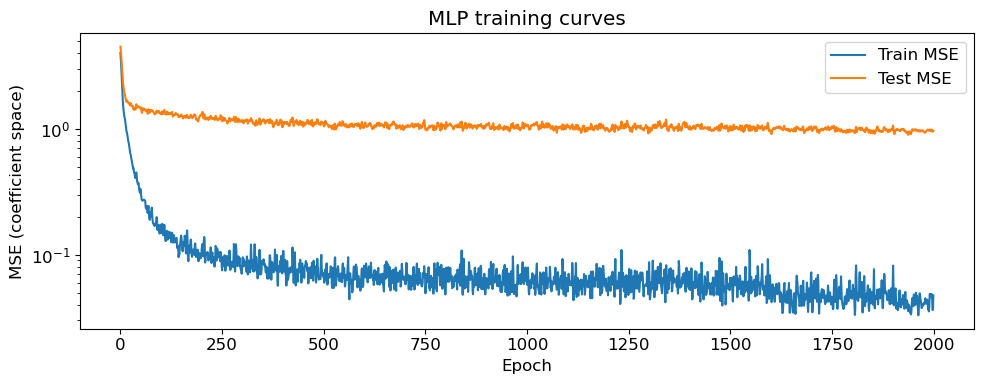

Final train MSE: 0.0474  |  test MSE: 0.9661


In [19]:
# Learning curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train MSE', lw=1.5)
ax.plot(test_losses,  label='Test MSE',  lw=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (coefficient space)')
ax.set_title('MLP training curves')
ax.set_yscale('log')
ax.legend()
plt.tight_layout(); plt.show()
print(f'Final train MSE: {train_losses[-1]:.4f}  |  test MSE: {test_losses[-1]:.4f}')

## 4. Evaluation — how well does the MLP reconstruct surfaces?

We decode the predicted coefficients back into surfaces via $\hat{Y} = \mu + \Phi \hat{C}$ and compare against the true GP surfaces.

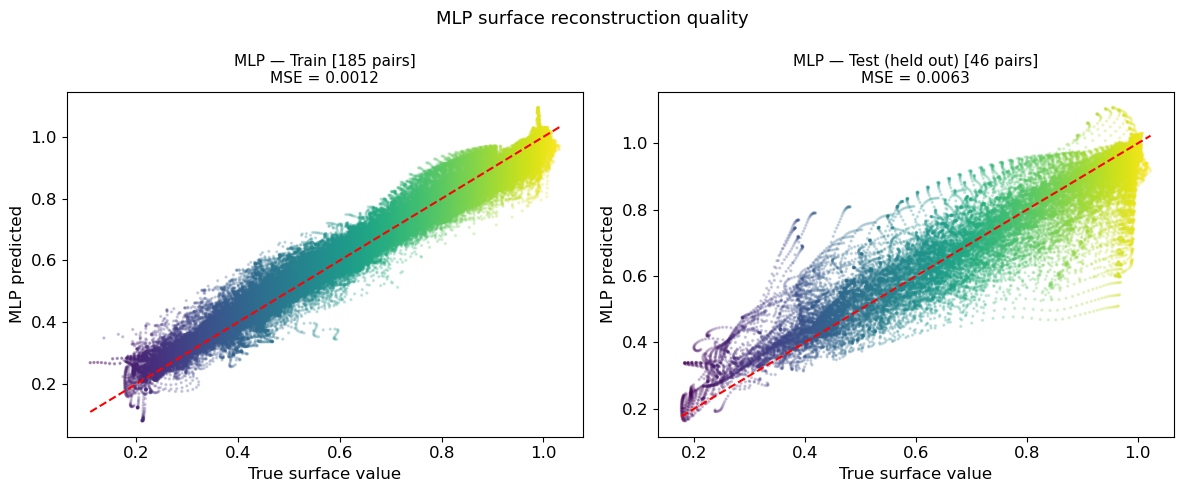

In [20]:
# Reconstruct surfaces from MLP-predicted coefficients
model.eval()
with torch.no_grad():
    C_pred_train = model(X_train_pca).T   # (K, N_train)
    C_pred_test  = model(X_test_pca).T    # (K, N_test)

Yhat_mlp_train = (mean_vec + Phi @ C_pred_train).numpy()
Yhat_mlp_test  = (mean_vec + Phi @ C_pred_test).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (Y, Yhat, label, n) in zip(axes, [
    (Y_train.numpy(), Yhat_mlp_train, 'Train',          len(train_idx)),
    (Y_test.numpy(),  Yhat_mlp_test,  'Test (held out)', len(test_idx)),
]):
    yt, yp = Y.flatten(), Yhat.flatten()
    mse = np.mean((yt - yp)**2)
    ax.scatter(yt, yp, alpha=0.2, s=2, c=yt, cmap='viridis')
    ax.plot([yt.min(), yt.max()], [yt.min(), yt.max()], 'r--', lw=1.5)
    ax.set_title(f'MLP — {label} [{n} pairs]\nMSE = {mse:.4f}', fontsize=11)
    ax.set_xlabel('True surface value'); ax.set_ylabel('MLP predicted')

plt.suptitle('MLP surface reconstruction quality', fontsize=13)
plt.tight_layout(); plt.show()

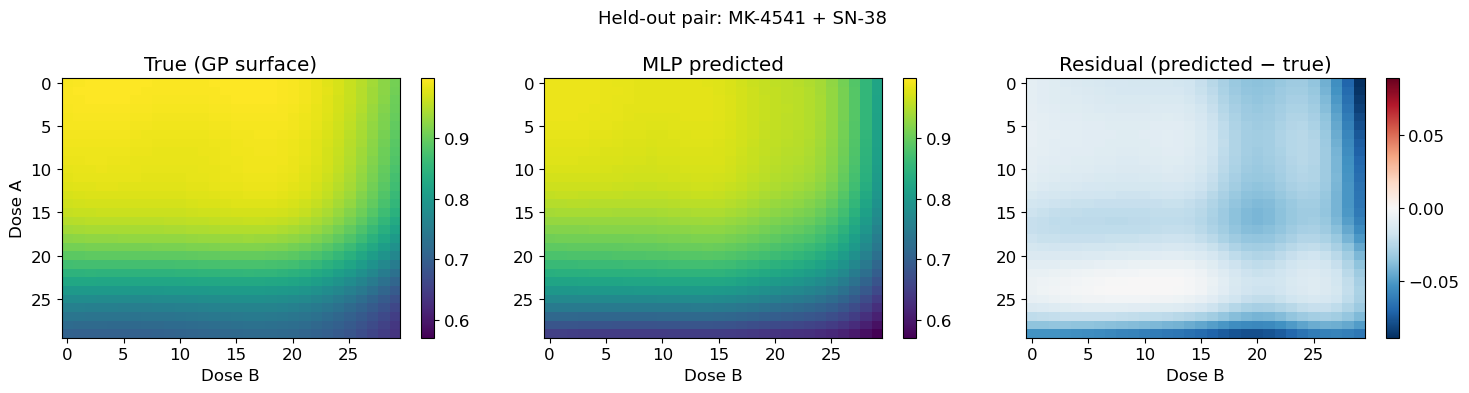

MK-4541 + SN-38  |  MSE = 0.0008


In [22]:
# Side-by-side: true vs MLP-predicted surface for a held-out pair
# Change pair_id (0 to N_test-1) to explore different pairs
pair_id = 19

true_surf = Y_test.numpy()[:, pair_id].reshape(G, G)
pred_surf = Yhat_mlp_test[:, pair_id].reshape(G, G)
pair_name = test_pairs.iloc[pair_id]['drugA'] + ' + ' + test_pairs.iloc[pair_id]['drugB']

vmin = min(true_surf.min(), pred_surf.min())
vmax = max(true_surf.max(), pred_surf.max())
lim  = np.abs(pred_surf - true_surf).max()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Held-out pair: {pair_name}', fontsize=13)

im1 = axes[0].imshow(true_surf, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
axes[0].set_title('True (GP surface)'); plt.colorbar(im1, ax=axes[0])
axes[0].set_xlabel('Dose B'); axes[0].set_ylabel('Dose A')

im2 = axes[1].imshow(pred_surf, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
axes[1].set_title('MLP predicted'); plt.colorbar(im2, ax=axes[1])
axes[1].set_xlabel('Dose B')

im3 = axes[2].imshow(pred_surf - true_surf, cmap='RdBu_r', vmin=-lim, vmax=lim, aspect='auto')
axes[2].set_title('Residual (predicted − true)'); plt.colorbar(im3, ax=axes[2])
axes[2].set_xlabel('Dose B')

plt.tight_layout(); plt.show()
print(f'{pair_name}  |  MSE = {np.mean((true_surf - pred_surf)**2):.4f}')

In [23]:
# List all held-out test pairs
print(f'{len(test_pairs)} held-out test pairs (set pair_id above to any of these):\n')
for i, (_, row) in enumerate(test_pairs.iterrows()):
    print(f'  [{i:3d}]  {row["drugA"]}  +  {row["drugB"]}')

46 held-out test pairs (set pair_id above to any of these):

  [  0]  MK-8669  +  MK-8776
  [  1]  Bortezomib  +  L778123
  [  2]  MK-5108  +  Oxaliplatin
  [  3]  MK-2206  +  Oxaliplatin
  [  4]  5-FU  +  PD325901
  [  5]  ABT-888  +  AZD1775
  [  6]  ABT-888  +  Lapatinib
  [  7]  MK-4541  +  MK-8669
  [  8]  MK-2206  +  Vinorelbine
  [  9]  MK-4541  +  MRK-003
  [ 10]  MK-5108  +  Vinorelbine
  [ 11]  MK-4827  +  PD325901
  [ 12]  MK-8776  +  MRK-003
  [ 13]  5-FU  +  geldanamycin
  [ 14]  PD325901  +  SN-38
  [ 15]  MK-8669  +  Oxaliplatin
  [ 16]  Bortezomib  +  MRK-003
  [ 17]  MK-2206  +  PD325901
  [ 18]  Lapatinib  +  SN-38
  [ 19]  MK-4541  +  SN-38
  [ 20]  Bortezomib  +  MK-5108
  [ 21]  ABT-888  +  MK-8669
  [ 22]  MK-4827  +  Methotrexate
  [ 23]  MK-5108  +  geldanamycin
  [ 24]  ABT-888  +  Bortezomib
  [ 25]  L778123  +  MK-4541
  [ 26]  AZD1775  +  L778123
  [ 27]  MK-8669  +  MRK-003
  [ 28]  Lapatinib  +  MK-8669
  [ 29]  L778123  +  Methotrexate
  [ 30]  MK-8669  +

## 5. Predict any drug pair by name

Given the names of any two drugs in the dataset, predict their viability surface directly from latent representations. If a true GP surface exists for that pair, it is shown alongside for comparison.

In [24]:
drug_latents_df = pd.read_csv('pimogp/data/cancer_drugs_latents.csv', index_col=0)
print('Available drugs:')
print(sorted(drug_latents_df.index.tolist()))

Available drugs:
['(+)-Bicuculline', '(+)-PD 128907 hydrochloride', '(+)-Usnic acid', '(+)-catechin', '(+/-)-2-AMINOHEPTANE SULFATE', "(+/-)-5'-Chloro-5'-deoxy-ENBA", '(+/-)-MCN 5652', '(+/-)-Norepinephrine (+)-bitartrate salt', '(-)-Epicatechin gallate', '(-)-Epigallocatechin gallate', '(-)-Eseroline fumarate', '(-)-MK 801 Maleate', '(-)-Quinpirole hydrochloride', '(-)-U-50488 HYDROCHLORIDE', '(-)-huperzine A', '(1-phenoxypropan-2-yl)hydrazine dihydrochloride', '(1R)-2-(methylamino)-1-phenyl-1-propanol', '(1S,3R)-ACPD', '(20S)-Protopanaxadiol', '(20S)-Protopanaxatriol', '(2S,4R)-4-Methylglutamic acid', '(5-fluoropyridin-3-yl)methanol', '(5Z)-7-Oxozeaenol', '(E)-3-[4-[[[(E)-(2,3-dihydroxy-4-oxo-cyclohexa-2,5-dien-1-ylidene)methyl]amino]carbamoyl]phenyl]prop-2-enehydroxamic acid', '(E,2S,3S,4S)-2-azaniumyl-3,4-dihydroxy-2-(hydroxymethyl)-14-oxo-icos-6-enoate', '(Phenylindolyl)maleimide deriv. 79', '(R)-4-Carboxy-3-hydroxyphenylglycine', '(R)-Tamsulosin-d3 Hydrochloride', '(RS)-(tetrazol

In [26]:
def predict_pair(drugA, drugB):
    missing = [d for d in [drugA, drugB] if d not in drug_latents_df.index]
    if missing:
        print(f'Not found: {missing}'); return

    zA = drug_latents_df.loc[drugA].values
    zB = drug_latents_df.loc[drugB].values
    x_pca = (np.concatenate([zA, zB]) - pca_mean.squeeze()) @ W_pca
    x_t   = torch.tensor(x_pca, dtype=torch.float32).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        c_pred  = model(x_t).squeeze()
    surface = (mean_vec.squeeze() + Phi @ c_pred).numpy().reshape(G, G)

    gp_path  = f'pimogp/surfaces/{drugA}_{drugB}_KPL1.txt'
    has_true = os.path.exists(gp_path)

    if has_true:
        true_surf = np.loadtxt(gp_path)
        vmin = min(surface.min(), true_surf.min())
        vmax = max(surface.max(), true_surf.max())
        lim  = np.abs(surface - true_surf).max()
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(f'{drugA} + {drugB}', fontsize=12)
        im1 = axes[0].imshow(true_surf, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
        axes[0].set_title('True (GP)'); plt.colorbar(im1, ax=axes[0])
        axes[0].set_xlabel('Dose B'); axes[0].set_ylabel('Dose A')
        im2 = axes[1].imshow(surface, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
        axes[1].set_title('MLP predicted'); plt.colorbar(im2, ax=axes[1])
        axes[1].set_xlabel('Dose B')
        im3 = axes[2].imshow(surface - true_surf, cmap='RdBu_r', vmin=-lim, vmax=lim, aspect='auto')
        axes[2].set_title('Residual'); plt.colorbar(im3, ax=axes[2])
        axes[2].set_xlabel('Dose B')
        plt.tight_layout(); plt.show()
        print(f'MSE vs true surface: {np.mean((surface - true_surf)**2):.4f}')
    else:
        fig, ax = plt.subplots(figsize=(5, 4))
        im = ax.imshow(surface, cmap='viridis', aspect='auto')
        ax.set_title(f'Predicted: {drugA} + {drugB}', fontsize=12)
        ax.set_xlabel('Dose B (log)'); ax.set_ylabel('Dose A (log)')
        plt.colorbar(im, ax=ax, label='Cell viability')
        plt.tight_layout(); plt.show()
        print(f'Surface range: [{surface.min():.3f}, {surface.max():.3f}]')

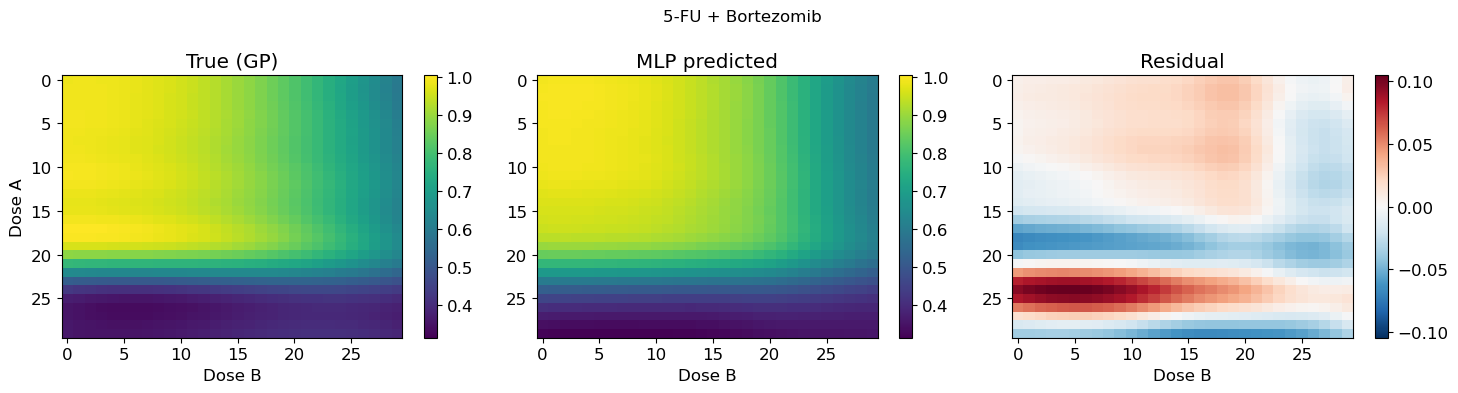

MSE vs true surface: 0.0011


In [27]:
# --- Change these to any two drug names ---
drug_a = '5-FU'
drug_b = 'Bortezomib'

predict_pair(drug_a, drug_b)